# Jackknife Tutorial

This notebook introduces the default `pyjack` workflow.

Key points:
- `pyjack` uses jackknife by default.
- Arithmetic and common functions propagate uncertainties automatically.
- The same observable can be passed directly to the fitting utilities.


In [1]:
import numpy
import pyjack
import matplotlib.pyplot as plt


## 1. Build a primary observable

The first axis of the input array is interpreted as the configuration axis.
Calling `create(data)` without additional options uses jackknife resampling.

In [2]:
numpy.random.seed(42)

data = numpy.random.randn(100, 10) * 0.3 + 4.0

obs = pyjack.observable(description='Tutorial observable')
obs.create(data)

print(obs)
print('resampling method =', obs.resampling_method)
print('mean shape =', obs.mean.shape)
print('covariance shape =', obs.cov.shape)


pyjack(4.001(26), 4.001(31), 3.985(30), 4.033(30), 4.024(31), 3.990(29), 3.986(28), 4.011(27), 4.009(27), 4.017(30), description=Tutorial observable)
resampling method = jackknife
mean shape = (10,)
covariance shape = (10, 10)


## 2. Propagate errors through arithmetic and functions

Operations act on the jackknife replicas internally, so derived observables keep their propagated uncertainties.

In [3]:
squared = obs ** 2
exponential = pyjack.exp(obs)
summed = obs @ numpy.ones(data.shape[1])

print('squared:', squared)
print('exponential:', exponential)
print('summed:', summed)


squared: pyjack(16.01(21), 16.01(25), 15.88(24), 16.26(24), 16.19(25), 15.92(23), 15.89(22), 16.09(21), 16.07(22), 16.14(24), description=Tutorial observable)
exponential: pyjack(54.7(14), 54.6(17), 53.8(16), 56.4(17), 55.9(17), 54.1(15), 53.8(15), 55.2(14), 55.1(15), 55.6(17), description=Tutorial observable)
summed: pyjack(40.058(94), description=Tutorial observable)


## 3. Slice observables and edit components

Slicing returns a derived observable. Assignments update the stored replicas and then recompute the statistical information.

In [4]:
sliced = obs[2:5]
obs[2:5] = 2.0 * sliced
updated = obs[2:5]

print('original slice:', sliced)
print('updated slice:', updated)


original slice: pyjack(3.985(30), 4.033(30), 4.024(31), description=Tutorial observable)
updated slice: pyjack(7.971(61), 8.065(60), 8.048(62), description=Tutorial observable)


## 4. Confidence intervals

For jackknife observables, the natural interval is the symmetric normal interval built from the mean and jackknife error.

If you request a bootstrap-specific interval method such as `percentile` or `bca`, `pyjack` reports a warning and falls back to the normal interval.

In [5]:
low, high = obs.confidence_interval(level=0.68, method='normal')
print('first component normal interval:', low[0], high[0])

# This falls back to the normal interval with a warning.
low_bca, high_bca = obs.confidence_interval(level=0.68, method='bca')
print('first component fallback interval:', low_bca[0], high_bca[0])


first component normal interval: 3.974405111304415 4.027765568922119
[pyjack.observable.confidence_interval] Warning: method='bca' is not available for jackknife observables. Using method='normal' instead.
first component fallback interval: 3.974405111304415 4.027765568922119


## 5. Fit directly from an observable

The fitting code consumes the observable mean and covariance matrix, so no manual error bookkeeping is required.

[jackfit.fit] Fit did converge: [LevenbergMarquardt.minimize] Convergence with tolerance 1e-08 reached after 10 iterations. Exiting successfully
[jackfit.fit] chi2obs = 7.836280954852306
[jackfit.fit] chi2exp = 7.815914787314818 +- 1.105337269457304
[jackfit.fit] p-value = 0.4395 +- 0.004963510717613531
pyjack(4.009(17), 0.0032(36), description=Best parameters of fit)


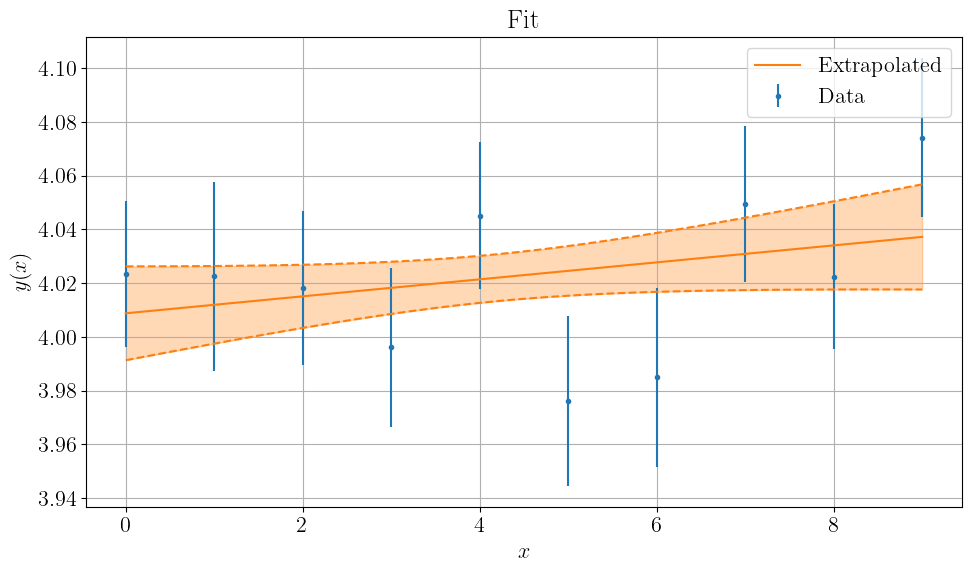

In [6]:
fit_data = numpy.random.randn(100, 10) * 0.3 + 4.0
fit_obs = pyjack.observable(description='Fit data')
fit_obs.create(fit_data)

fitfunc = 'params0 + params1 * x'
initial_guess = [3.0, 0.0]
W = 'diag'

fit1 = pyjack.jackfit(fitfunc, W, initial_guess)
fit1.fit(numpy.arange(fit_obs.data.shape[1]), fit_obs, max_iter=1000, tol=1e-8, num_samples=10000)
print(fit1.params)
fit1.plot()


## 6. Increase statistics

For a primary observable you can append more configurations and rebuild the jackknife analysis.

In [7]:
new_data = numpy.random.randn(1000, 10) * 0.3 + 4.0
fit_obs.increase_statistics(new_data)

fit2 = pyjack.jackfit(fitfunc, W, initial_guess)
fit2.fit(numpy.arange(fit_obs.data.shape[1]), fit_obs, max_iter=1000, tol=1e-8, num_samples=10000)
print(fit2.params)


[jackfit.fit] Fit did converge: [LevenbergMarquardt.minimize] Convergence with tolerance 1e-08 reached after 2 iterations. Exiting successfully
[jackfit.fit] chi2obs = 13.737578528548969
[jackfit.fit] chi2exp = 7.931180797575983 +- 0.3381866855178123
[jackfit.fit] p-value = 0.0848 +- 0.002785977775793756
pyjack(4.0059(54), -0.0013(10), description=Best parameters of fit)
